# DCB benchmarks: Krueger (2008), NASA/TM-2008-215123

R. Krueger, *An Approach to Assess Delamination Propagation Simulation Capabilities in Commercial Finite Element Codes*, NASA/TM-2008-215123, National Institute of Aerospace / NASA Langley Research Center, 2008.

The report creates benchmark solutions for three specimens and uses them to assess the delamination propagation capability of VCCT for ABAQUS. Two of them are pure mode I Double Cantilever Beam (DCB) specimens and are included here; the third, the Single Leg Bending (SLB) specimen, is mixed mode I/II ($G_S/G_T \approx 0.35$ at mid-width, Fig. 42) and is not included, for the same reason as the MMB cases of `krueger2012_mmb_benchmark.ipynb`: the damage of the `SB_TSL` connection of panels is driven by the normal separation only.

## Mode I DCB cases of the report

| case | sections | layup | material | $B$ (mm) | $2h$ (mm) | $2L$ (mm) | $a_0$ (mm) | $G_{Ic}$ (J/m$^2$) |
|---|---|---|---|---|---|---|---|---|
| DCB-UD | 5.1, 5.2 | $[0]_{24}$ | T300/1076 (elastic), T300/914C ($G_{Ic}$) | 25.0 | 3.0 | 150.0 | 30 | 170.3 |
| DCB-MD | 5.3, 5.4 | D$\pm$30 | C12K/R6376 | 25.4 | 4.0 | 177.8 | 31 | 340.5 |

The D$\pm$30 stacking sequence is $[\pm 30/0/-30/0/30/0_4/30/0/-30/0/-30/30/\!\uparrow\!-30/30/0/30/0/-30/0_4/-30/0/30/0/\pm 30]$ (Section 2), 32 plies, the arrow marking the delamination at the mid-plane. Each arm is therefore the 16-ply laminate $[30/-30/0/-30/0/30/0_4/30/0/-30/0/-30/30]$ of 2.0 mm, i.e. plies of 0.125 mm, which is symmetric about its own mid-plane; the other arm is its mirror, with all angles of opposite sign. Both have the same $\mathbf{A}$, $\mathbf{B} = \mathbf{0}$ and the same $\mathbf{D}$, with $D_{16} = D_{26} = 0$ (the $\pm 30$ contributions cancel exactly), so the single `stack` of `dcb_utils`, which is used for both arms, represents this laminate exactly.

Table I of the report: T300/1076 $E_{11} = 139.4$, $E_{22} = E_{33} = 10.16$, $G_{12} = G_{13} = 4.6$, $G_{23} = 3.54$ GPa, $\nu_{12} = \nu_{13} = 0.30$, $\nu_{23} = 0.436$; C12K/R6376 $E_{11} = 146.9$, $E_{22} = E_{33} = 10.6$, $G_{12} = G_{13} = 5.45$, $G_{23} = 3.99$ GPa, $\nu_{12} = \nu_{13} = \nu_{23} = 0.33$.

## What the benchmark is

The report uses the **virtual crack closure technique (VCCT)**, not a cohesive law. For each specimen, 3D models (C3D8I solid bricks, a refined mesh of 0.25 mm at the front) were built for a set of delamination lengths $a$ and solved for one applied opening, $\delta/2 = 1$ mm per arm. From these linear results the benchmark is the *onset of delamination at mid-width*: the failure index $G_T/G_c$ at $y/B = 0$ (Figs. 12 and 35) is brought to unity with Eq. (5) of the report,

$$\frac{G_T}{G_c} = \frac{P^2}{P_{crit}^2} \quad \Rightarrow \quad P_{crit} = P\sqrt{\frac{G_c}{G_T}}, \qquad \delta_{crit} = \delta\sqrt{\frac{G_c}{G_T}},$$

which gives the red curves of Figs. 14 and 37. Three benchmark quantities are defined: the critical load--displacement curve (Figs. 14, 37), the critical delamination length against the displacement and against the load (Figs. 21, 22) and the total strain energy $U = P\delta/2$, Eq. (6) (Figs. 25, 26, 39).

The benchmark is therefore **linear elastic fracture mechanics evaluated locally at mid-width**, not an energy balance over the width. This matters for the comparison and is discussed at the end.

The propagation analyses of the report (Figs. 15--20, 38) follow the benchmark with a saw-tooth whose amplitude grows with the element size at the front, and only after tuning the release tolerance together with the global stabilization, the contact stabilization or the viscous regularization; the damping energy reaches 5--25% of the total strain energy for the DCB-UD and about 11--20% for the DCB-MD. The report concludes that selecting the input parameters "was not straightforward and often required an iterative procedure". Those curves are not digitised here: the benchmark is the quantity the report proposes for comparison, and the propagation results scatter around it.

## No experiment and no interfacial strength

The report gives **no experimental load--displacement data** for the DCB; the only test result is the scan of a fractured DCB in Fig. 33a, used to compare the shape of the delamination front. `exp_tests` is therefore empty.

VCCT has **no interfacial strength**, so $\tau_o$ is not given and has to be chosen for panels. Two values are used, $\tau_o = 40$ and 60 MPa, which bracket the usual range for carbon/epoxy interfaces, and the difference between them measures how much the comparison depends on that choice.

## Inconsistencies of the report

- Fig. 3a labels the unidirectional DCB "T300/914C $[0]_{24}$" while Section 2 states that it is made of T300/1076; Table I gives the elastic properties of T300/1076 only, and Section 5.1 uses $G_{Ic} = 170.3$ J/m$^2$, the mode I toughness of T300/914C of Fig. 2a. The elastic properties of Table I and $G_{Ic} = 170.3$ J/m$^2$ are used here, as in Section 5.1.
- The dimension boxes of Figs. 7 and 8 ($B = 25.4$, $2L = 177.8$, $t_1 = t_2 = 2.0$, $a = 34.0$ mm) repeat those of the SLB models of Figs. 9 and 10. For the DCB-MD the benchmark covers $a = 31$--40 mm (Figs. 34--37) and the propagation analysis starts at $a = 31$ mm (Section 5.4.1), so $a_0 = 31$ mm is used here. The last line of Section 5.3 says $a = 30$ mm, which contradicts Figs. 34--37.

## Conventions

The report plots the load against $\delta/2$, the opening applied to **each** arm; the $\delta$ of panels and of `dcb_utils` is the **total** opening, $\delta = 2(\delta/2)$. All curves below are in the convention of panels.

## Digitised data

Figs. 11, 13, 34 and 36 were read by eye at $y/B = 0$ and at $\delta/2 = 1$ mm, with an estimated uncertainty of $\pm 5$ J/m$^2$ and $\pm 1$ N. The failure indices of Figs. 12 and 35 are reproduced by $G_I/G_{Ic}$ from these readings within the reading accuracy, the critical points derived with Eq. (5) reproduce the red curves of Figs. 14 and 37, and the value $\delta_{crit}/2 = 0.75$ mm stated in Section 5.2.1 for $a_0 = 30$ mm is recovered.

In [1]:
import os
import sys

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

sys.path.insert(0, os.path.abspath('.'))
import dcb_utils as du

# True runs panels again, otherwise the results saved in RESULTS are loaded
RERUN = False
RESULTS = 'results'
# comma-separated keys, runs only these cases (used to run cases in parallel)
ONLY = os.environ.get('DCB_CASES')
ONLY = ONLY.split(',') if ONLY else None

## FE-based DCB cases

`P1` is the load at $\delta/2 = 1$ mm (Figs. 13 and 36) and `GI` the mode I energy release rate at $y/B = 0$ for the same opening (Figs. 11 and 34), for each delamination length of `a_bench`.

In [2]:
t300_1076 = dict(E1=139400., E2=10160., nu12=0.30, G12=4600.)    # Table I
c12k_r6376 = dict(E1=146900., E2=10600., nu12=0.33, G12=5450.)   # Table I
# one arm of the D+-30 laminate, 16 plies of 0.125 mm, see the header
arm_D30 = [30, -30, 0, -30, 0, 30, 0, 0, 0, 0, 30, 0, -30, 0, -30, 30]

fe_cases = {
    'DCB_UD': dict(t300_1076, h=1.5, b=25., L=150., a0=30., G1c=0.1703,
        label='DCB, unidirectional $[0]_{24}$',
        source='Figs. 3a, 5, 11-14, 21, 22, 25, 26; Table I',
        model='ABAQUS/Standard, C3D8I solid bricks, 6 elements through 2h, 0.25 mm at '
              'the front, VCCT; G_Ic = 170.3 J/m2 of T300/914C (Fig. 2a)',
        a_bench=np.array([30., 31., 32., 33., 34., 35., 40.]),
        P1=np.array([81.0, 74.0, 68.0, 62.5, 57.5, 52.5, 36.7]),   # Fig. 13
        GI=np.array([303., 270., 240., 215., 192., 170., 105.]),   # Fig. 11
        fig_fi='Fig. 12'),
    'DCB_MD': dict(c12k_r6376, stack=arm_D30, plyt=0.125, b=25.4, L=177.8, a0=31.,
        G1c=0.3405,
        label=r'DCB, multidirectional D$\pm$30',
        source='Figs. 3a, 8, 34-40; Table I',
        model='ABAQUS/Standard, C3D8I solid bricks, the two plies on each side of the '
              'delamination modelled individually and the others smeared, VCCT; '
              'G_Ic = 340.5 J/m2 of C12K/R6376 (Fig. 2b)',
        a_bench=np.array([31., 32., 33., 34., 35., 40.]),
        P1=np.array([128.0, 117.5, 108.0, 99.5, 91.5, 63.0]),      # Fig. 36
        GI=np.array([532., 478., 425., 378., 342., 212.]),         # Fig. 34
        fig_fi='Fig. 35'),
}

# no experimental load-displacement data in NASA/TM-2008-215123, see the header
exp_tests = {}

### Benchmark of the report, Eq. (5)

`failure_index` is $G_T/G_c$ at $\delta/2 = 1$ mm, to be compared with Figs. 12 and 35; `benchmark` returns the critical load--opening curve of Figs. 14 and 37, with the linear branch of the $a_0$ specimen up to its critical point.

In [3]:
def failure_index(fe):
    r"""Failure index $G_T/G_c$ at mid-width and $\delta/2 = 1$ mm, Figs. 12 and 35"""
    return fe['GI']/1000./fe['G1c']      # GI in J/m2, G1c in N/mm = 1000 J/m2


def benchmark(fe, n_lin=4):
    """Critical load-opening curve, Eq. (5) of the report

    Returns ``(delta, P)`` in the convention of panels, ``delta`` being the
    total opening. ``n_lin`` points are added on the linear branch of the
    ``a0`` specimen, which the report draws from the origin to the first
    critical point (Figs. 14 and 37).

    """
    s = np.sqrt(1./failure_index(fe))    # = delta_crit/2 (mm), since delta/2 = 1 mm
    P, delta = fe['P1']*s, 2*s
    lin = np.linspace(0., 1., n_lin + 1)[:-1]
    return (np.concatenate((lin*delta[0], delta)),
            np.concatenate((lin*P[0], P)))


table = []
for key, fe in fe_cases.items():
    d, P = benchmark(fe, n_lin=0)
    for a, f, dd, pp in zip(fe['a_bench'], failure_index(fe), d, P):
        table.append(f"| {fe['label']} | {a:.0f} | {f:.2f} | {dd/2:.3f} | {pp:.1f} |")
display(Markdown(
    'Failure index and critical point of each delamination length; the failure indices '
    'are to be compared with Figs. 12 and 35 and the critical points with the red '
    'curves of Figs. 14 and 37:\n\n'
    '| case | $a$ (mm) | $G_T/G_c$ | $\\delta_{crit}/2$ (mm) | $P_{crit}$ (N) |\n'
    '|---|---|---|---|---|\n' + '\n'.join(table)))

Failure index and critical point of each delamination length; the failure indices are to be compared with Figs. 12 and 35 and the critical points with the red curves of Figs. 14 and 37:

| case | $a$ (mm) | $G_T/G_c$ | $\delta_{crit}/2$ (mm) | $P_{crit}$ (N) |
|---|---|---|---|---|
| DCB, unidirectional $[0]_{24}$ | 30 | 1.78 | 0.750 | 60.7 |
| DCB, unidirectional $[0]_{24}$ | 31 | 1.59 | 0.794 | 58.8 |
| DCB, unidirectional $[0]_{24}$ | 32 | 1.41 | 0.842 | 57.3 |
| DCB, unidirectional $[0]_{24}$ | 33 | 1.26 | 0.890 | 55.6 |
| DCB, unidirectional $[0]_{24}$ | 34 | 1.13 | 0.942 | 54.2 |
| DCB, unidirectional $[0]_{24}$ | 35 | 1.00 | 1.001 | 52.5 |
| DCB, unidirectional $[0]_{24}$ | 40 | 0.62 | 1.274 | 46.7 |
| DCB, multidirectional D$\pm$30 | 31 | 1.56 | 0.800 | 102.4 |
| DCB, multidirectional D$\pm$30 | 32 | 1.40 | 0.844 | 99.2 |
| DCB, multidirectional D$\pm$30 | 33 | 1.25 | 0.895 | 96.7 |
| DCB, multidirectional D$\pm$30 | 34 | 1.11 | 0.949 | 94.4 |
| DCB, multidirectional D$\pm$30 | 35 | 1.00 | 0.998 | 91.3 |
| DCB, multidirectional D$\pm$30 | 40 | 0.62 | 1.267 | 79.8 |

## panels model

The DCB is modelled with `dcb_utils.solve_dcb`: CLPT panels, far end clamped, arm tips opened symmetrically to $\pm\delta/2$ by prescribed displacements, a cohesive domain (`SB_TSL`, bilinear law) ahead of the initial crack front and a perfect bond (`SB`) over the rest of the bonded region. The load is the reaction of the prescribed displacement.

Discretisation, from the convergence study of `theory/multidomain_penalization/cohesive_zone_deviations_from_thesis.tex`:

- terms along $x$ of the cohesive domain: $m_{tsl} = 1.5\,\lambda\,L_{tsl}$, with $\lambda = (k_o/4D_{11})^{1/4}$ the decay rate of the opening ahead of the process zone, at most 25;
- Gauss columns: $n_x = 10\,L_{tsl}/l_{cz}$, with $l_{cz} = 0.88\,E_2 G_{Ic}/\tau_o^2$ (Turon et al. 2007), at most 300, the Gauss--Legendre rules of panels going up to 304 points;
- the cohesive domain covers the crack growth up to the last opening plus a margin of $2\pi/\lambda + 3 l_{cz}$ for the process zone and the compressive lobe ahead of it; the opening range is limited so that $L_{tsl}$ stays below the length resolved with 25 terms.

The penalty stiffness is $k_o = 10^5$ N/mm$^3$, as in the other validation notebooks; the report has no penalty stiffness, VCCT being a nodal release technique.

In [4]:
def setup(case, k_o=1.e5, growth_max=None, n_steps=60):
    """Cohesive domain, discretisation and openings of a panels run"""
    c = dict(case)
    c['k_o'] = k_o
    lam, lcz, L_max = du.resolution(c)
    margin = 2*np.pi/lam + 3*lcz
    L_avail = c['L'] - c['a0']
    growth = min(L_max, L_avail) - margin
    if growth_max is not None:
        growth = min(growth, growth_max)
    L_tsl = min(growth + margin, L_avail)
    c = du.discretize(c, L_tsl)
    # opening when the crack reaches a0 + growth, corrected beam theory
    EI = du.D11(c)*c['b']
    dh = du.chi_williams(du.bending_modulus(c), c['E2'], c['G12'])*du.arm_thickness(c)
    ae = c['a0'] + growth + dh
    delta_max = 2/3*ae**2*np.sqrt(c['G1c']*du._bonded_width(c)/EI)
    openings = np.linspace(delta_max/n_steps, delta_max, n_steps)
    print(f"{case.get('label', '')}: lambda={lam:.3f} 1/mm, lcz={lcz:.2f} mm, "
          f"L_tsl={c['L_tsl']:.1f} mm, m_tsl={c['m_tsl']}, nx={c['nx']}, "
          f"growth={growth:.1f} mm, delta_max={delta_max:.2f} mm")
    return c, openings


def run(key, case, openings, path):
    if ONLY is not None and key not in ONLY:
        return None
    return du.run_or_load(case, openings, path, rerun=RERUN)


def curve(res):
    return np.concatenate(([0.], res['delta'])), np.concatenate(([0.], res['P']))


# the report gives no interfacial strength, see the header
TAUS = (40., 60.)

In [5]:
runs = {}
for key, fe in fe_cases.items():
    for tau in TAUS:
        tag = f'{key}_tau{tau:.0f}'
        case, openings = setup(dict(fe, tau_o=tau,
                                    label=f"{fe['label']}, tau_o = {tau:.0f} MPa"))
        runs[tag] = (case, run(tag, case, openings, f'{RESULTS}/krueger2008_{tag}.npz'))

DCB, unidirectional $[0]_{24}$, tau_o = 40 MPa: lambda=0.892 1/mm, lcz=0.95 mm, L_tsl=18.7 mm, m_tsl=25, nx=200, growth=8.8 mm, delta_max=2.41 mm
DCB, unidirectional $[0]_{24}$, tau_o = 60 MPa: lambda=0.892 1/mm, lcz=0.42 mm, L_tsl=18.7 mm, m_tsl=25, nx=300, growth=10.4 mm, delta_max=2.59 mm


DCB, multidirectional D$\pm$30, tau_o = 40 MPa: lambda=0.773 1/mm, lcz=1.99 mm, L_tsl=21.6 mm, m_tsl=25, nx=110, growth=7.5 mm, delta_max=2.55 mm


DCB, multidirectional D$\pm$30, tau_o = 60 MPa: lambda=0.773 1/mm, lcz=0.88 mm, L_tsl=21.6 mm, m_tsl=25, nx=250, growth=10.8 mm, delta_max=2.98 mm


## Comparison

The reference of LEFM is beam theory under displacement control with the bending stiffness $D_{11} b$ of one arm, simple (SBT) and with the crack length correction of Williams (CBT). For the multidirectional arms the bending modulus $12 D_{11}/h^3$ replaces $E_{11}$ in the correction.

In [6]:
def style_of(rows):
    style = {}
    for k in rows:
        if k.startswith('panels'):
            first = '40' in k
            style[k] = dict(lw=2 if first else 1.6, color='k' if first else '0.45',
                            ls='-' if first else '--')
        elif k.startswith('benchmark'):
            style[k] = dict(marker='o', ms=4, color='C3', lw=1.5)
        elif 'LEFM' in k:
            style[k] = dict(ls=':' if 'simple' in k else '--', lw=1)
        else:
            style[k] = dict(marker='s', ms=3)
    return style


def compare(key):
    fe = fe_cases[key]
    ref = f"benchmark, Eq. (5) ({fe['fig_fi']})"
    rows = {ref: benchmark(fe)}
    for tau in TAUS:
        rows[f'panels, $\\tau_o$ = {tau:.0f} MPa'] = curve(runs[f'{key}_tau{tau:.0f}'][1])
    rows['LEFM, simple beam theory'] = du.lefm_curve(fe, fe['a0'] + 20)
    rows['LEFM, corrected beam theory'] = du.lefm_curve(fe, fe['a0'] + 20, corrected=True)
    dmax = max(d.max() for d, _ in rows.values() if len(d) < 100)
    display(Markdown(f"### {fe['label']}\n\n" + du.markdown_table(rows, ref=[ref])))
    fig, ax = plt.subplots(figsize=(7, 4.5))
    du.plot_curves(ax, rows, style_of(rows))
    ax.set_xlim(0, 1.05*dmax)
    ax.set_title(fe['label'] + ' (Krueger 2008)')
    plt.show()
    for tau in TAUS:
        case, res = runs[f'{key}_tau{tau:.0f}']
        print(f"panels tau_o={tau:.0f}: m_tsl={case['m_tsl']}, nx={case['nx']}, "
              f"{len(res['delta'])} openings, {res['failed']} bisections, "
              f"crack growth {res['a'][-1] - fe['a0']:.1f} mm, "
              f"max|P - P_traction| = {np.abs(res['P'] - res['P_traction']).max():.1e} N, "
              f"{float(res['time'])/3600:.2f} h")

### DCB, unidirectional $[0]_{24}$

| curve | K0 (N/mm) | Pmax (N) | delta at Pmax (mm) | dK0, dPmax, d(delta) vs benchmark, Eq. (5) (Fig. 12) |
|---|---|---|---|---|
| benchmark, Eq. (5) (Fig. 12) | 40.50 | 60.7 | 1.50 | - |
| panels, $\tau_o$ = 40 MPa | 49.10 | 63.6 | 1.40 | +21.2%, +4.7%, -6.4% |
| panels, $\tau_o$ = 60 MPa | 49.55 | 64.2 | 1.38 | +22.3%, +5.8%, -7.8% |
| LEFM, simple beam theory | 54.81 | 68.3 | 1.25 | +35.3%, +12.5%, -16.9% |
| LEFM, corrected beam theory | 41.55 | 62.3 | 1.50 | +2.6%, +2.6%, -0.0% |

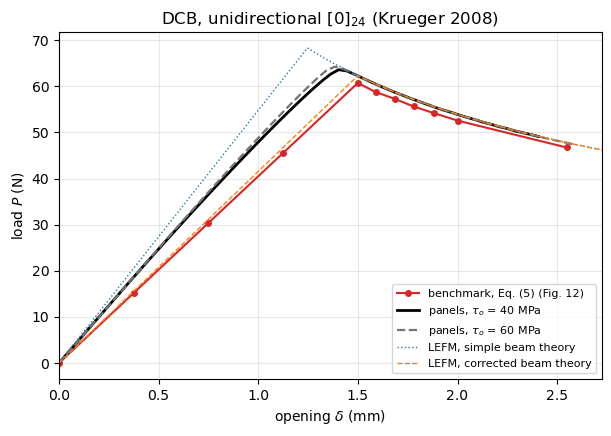

panels tau_o=40: m_tsl=25, nx=200, 60 openings, 0 bisections, crack growth 9.9 mm, max|P - P_traction| = 3.3e-01 N, 1.79 h
panels tau_o=60: m_tsl=25, nx=300, 60 openings, 0 bisections, crack growth 11.8 mm, max|P - P_traction| = 9.3e-01 N, 1.98 h


In [7]:
compare('DCB_UD')

### DCB, multidirectional D$\pm$30

| curve | K0 (N/mm) | Pmax (N) | delta at Pmax (mm) | dK0, dPmax, d(delta) vs benchmark, Eq. (5) (Fig. 35) |
|---|---|---|---|---|
| benchmark, Eq. (5) (Fig. 35) | 64.00 | 102.4 | 1.60 | - |
| panels, $\tau_o$ = 40 MPa | 73.15 | 108.7 | 1.70 | +14.3%, +6.1%, +6.4% |
| panels, $\tau_o$ = 60 MPa | 74.76 | 109.9 | 1.64 | +16.8%, +7.4%, +2.3% |
| LEFM, simple beam theory | 89.49 | 126.5 | 1.41 | +39.8%, +23.5%, -11.7% |
| LEFM, corrected beam theory | 66.68 | 114.7 | 1.72 | +4.2%, +12.0%, +7.5% |

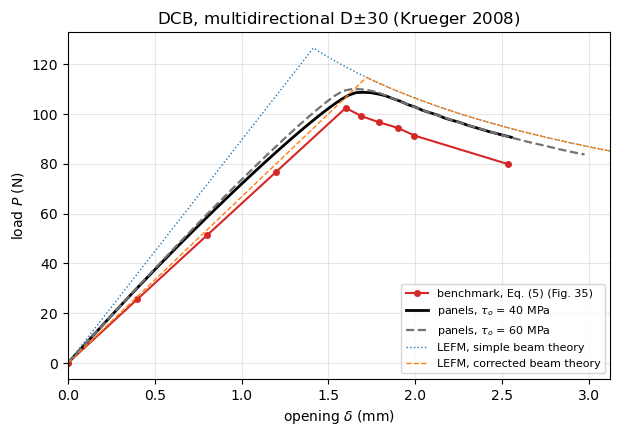

panels tau_o=40: m_tsl=25, nx=110, 60 openings, 0 bisections, crack growth 7.6 mm, max|P - P_traction| = 2.6e-02 N, 1.51 h
panels tau_o=60: m_tsl=25, nx=250, 60 openings, 0 bisections, crack growth 11.4 mm, max|P - P_traction| = 4.4e-01 N, 1.78 h


In [8]:
compare('DCB_MD')

### Delamination length and total strain energy

The two other benchmark quantities of the report: the critical delamination length against the applied opening and against the load (Figs. 21 and 22, and the same construction for the DCB-MD) and the total strain energy $U = P\delta/2$, Eq. (6) (Figs. 25 and 26 for the DCB-UD, Fig. 39 for the DCB-MD), in joules as in those figures. The crack length of panels is the position of the last fully damaged Gauss point at mid-width that is connected to the initial front.

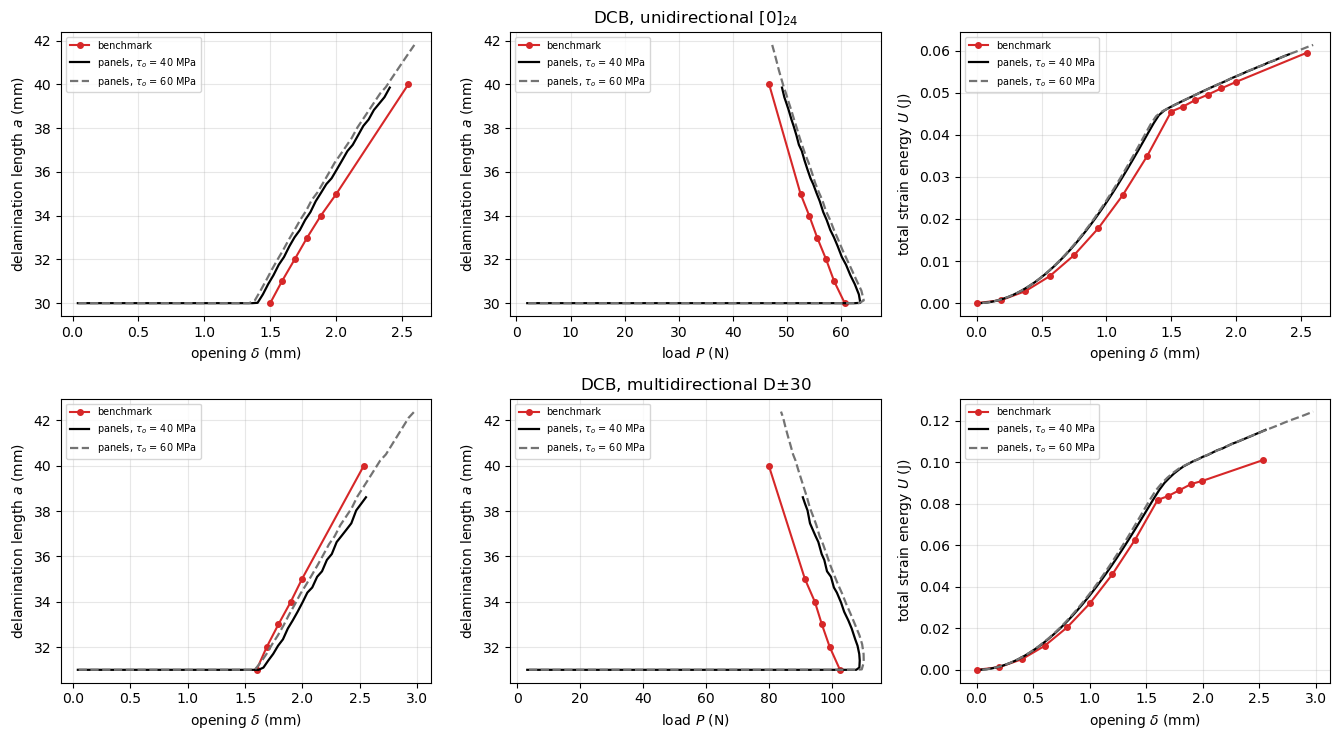

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(13.5, 7.5))
for row, (key, fe) in zip(axes, fe_cases.items()):
    d_b, P_b = benchmark(fe, n_lin=0)
    # the linear branch of the a0 specimen, where U grows quadratically
    d_u, P_u = benchmark(fe, n_lin=8)
    panels = [(tau, runs[f'{key}_tau{tau:.0f}'][1]) for tau in TAUS]
    # (x of the benchmark, y of the benchmark, x of panels, y of panels, labels)
    # U = P*delta/2 in N mm = mJ, converted to the joules of Figs. 25, 26 and 39
    plots = [(d_b, fe['a_bench'], lambda r: r['delta'], lambda r: r['a'],
              r'opening $\delta$ (mm)', 'delamination length $a$ (mm)'),
             (P_b, fe['a_bench'], lambda r: r['P'], lambda r: r['a'],
              r'load $P$ (N)', 'delamination length $a$ (mm)'),
             (d_u, P_u*d_u/2000., lambda r: r['delta'],
              lambda r: r['P']*r['delta']/2000., r'opening $\delta$ (mm)',
              'total strain energy $U$ (J)')]
    for ax, (xb, yb, fx, fy, xl, yl) in zip(row, plots):
        ax.plot(xb, yb, 'o-', color='C3', ms=4, lw=1.5, label='benchmark')
        for (tau, res), ls, col in zip(panels, ('-', '--'), ('k', '0.45')):
            ax.plot(fx(res), fy(res), ls, color=col, lw=1.6,
                    label=f'panels, $\\tau_o$ = {tau:.0f} MPa')
        ax.set_xlabel(xl)
        ax.set_ylabel(yl)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=7)
    row[1].set_title(fe['label'])
plt.tight_layout()
plt.show()

### Crack growth and load at the last opening against LEFM

`dcb_utils.a_at_opening` gives the crack length that the corrected beam theory reaches at an opening, and `lefm_curve` its propagation branch.

In [10]:
lines = ['| case | $\\tau_o$ (MPa) | $\\Delta a$ (mm) | $a$ at the last opening (mm) '
         '| CBT (mm) | diff. (mm) | $P$ at the last opening (N) | CBT (N) | diff. |',
         '|---|---|---|---|---|---|---|---|---|']
for key, fe in fe_cases.items():
    for tau in TAUS:
        case, res = runs[f'{key}_tau{tau:.0f}']
        d = res['delta'][-1]
        d_l, P_l = du.lefm_curve(fe, fe['a0'] + 30, corrected=True)
        a_cbt, P_cbt = du.a_at_opening(fe, d, corrected=True), float(np.interp(d, d_l, P_l))
        lines.append(f"| {fe['label']} | {tau:.0f} | {res['a'][-1] - fe['a0']:.1f} "
                     f"| {res['a'][-1]:.1f} | {a_cbt:.1f} | {res['a'][-1] - a_cbt:+.1f} "
                     f"| {res['P'][-1]:.1f} | {P_cbt:.1f} "
                     f"| {100*(res['P'][-1]/P_cbt - 1):+.1f}% |")
display(Markdown('\n'.join(lines)))

| case | $\tau_o$ (MPa) | $\Delta a$ (mm) | $a$ at the last opening (mm) | CBT (mm) | diff. (mm) | $P$ at the last opening (N) | CBT (N) | diff. |
|---|---|---|---|---|---|---|---|---|
| DCB, unidirectional $[0]_{24}$ | 40 | 9.9 | 39.9 | 38.8 | +1.1 | 49.1 | 49.2 | -0.1% |
| DCB, unidirectional $[0]_{24}$ | 60 | 11.8 | 41.8 | 40.4 | +1.4 | 47.3 | 47.4 | -0.1% |
| DCB, multidirectional D$\pm$30 | 40 | 7.6 | 38.6 | 38.5 | +0.1 | 90.6 | 94.1 | -3.7% |
| DCB, multidirectional D$\pm$30 | 60 | 11.4 | 42.4 | 41.8 | +0.6 | 83.7 | 87.2 | -4.0% |

### Mid-width onset against the width average

The benchmark brings $G_T$ to $G_c$ **at mid-width**, where the three-dimensional
energy release rate is highest, while a cohesive model and beam theory dissipate
$G_{Ic}$ over the whole front, i.e. they follow the width average. At the critical
point of the benchmark the width average of beam theory is

$$\bar{G} = \frac{P_{crit}^2\,a_e^2}{b\,E I}, \qquad a_e = a + \chi h,$$

and, since the mid-width value there is $G_c$ by construction, $G_c/\bar{G}$ is
how much the distribution peaks at mid-width. A model driven by $\bar{G}$ reaches
$G_{Ic}$ at a load $\sqrt{G_c/\bar{G}}$ times the benchmark load, which is the
whole difference between the benchmark and the corrected beam theory in the tables
above.

In [11]:
lines = ['| case | $a$ (mm) | $P_{crit}$ (N) | $\\bar{G}$ (J/m$^2$) | $G_c/\\bar{G}$ '
         '| $\\sqrt{G_c/\\bar{G}}$ |', '|---|---|---|---|---|---|']
notes = []
for key, fe in fe_cases.items():
    EI = du.D11(fe)*fe['b']
    dh = du.chi_williams(du.bending_modulus(fe), fe['E2'], fe['G12'])*du.arm_thickness(fe)
    _, P = benchmark(fe, n_lin=0)
    ae = fe['a_bench'] + dh
    Gbar = 1000.*P**2*ae**2/(fe['b']*EI)                    # J/m2
    for a, p, g in zip(fe['a_bench'], P, Gbar):
        r = 1000.*fe['G1c']/g
        lines.append(f"| {fe['label']} | {a:.0f} | {p:.1f} | {g:.1f} | {r:.3f} "
                     f"| {np.sqrt(r):.3f} |")
    cbt = du.summary(*du.lefm_curve(fe, fe['a0'] + 20, corrected=True))['Pmax']
    notes.append(f"- {fe['label']}: mean $\\sqrt{{G_c/\\bar{{G}}}}$ = "
                 f"{np.sqrt(1000.*fe['G1c']/Gbar).mean():.3f}, against a ratio of the peak "
                 f"of the corrected beam theory to the peak of the benchmark of "
                 f"{cbt/P[0]:.3f} ({cbt:.1f} N / {P[0]:.1f} N).")
display(Markdown('\n'.join(lines) + '\n\n' + '\n'.join(notes)))

| case | $a$ (mm) | $P_{crit}$ (N) | $\bar{G}$ (J/m$^2$) | $G_c/\bar{G}$ | $\sqrt{G_c/\bar{G}}$ |
|---|---|---|---|---|---|
| DCB, unidirectional $[0]_{24}$ | 30 | 60.7 | 161.8 | 1.052 | 1.026 |
| DCB, unidirectional $[0]_{24}$ | 31 | 58.8 | 160.9 | 1.058 | 1.029 |
| DCB, unidirectional $[0]_{24}$ | 32 | 57.3 | 162.0 | 1.051 | 1.025 |
| DCB, unidirectional $[0]_{24}$ | 33 | 55.6 | 161.7 | 1.053 | 1.026 |
| DCB, unidirectional $[0]_{24}$ | 34 | 54.2 | 161.9 | 1.052 | 1.026 |
| DCB, unidirectional $[0]_{24}$ | 35 | 52.5 | 160.8 | 1.059 | 1.029 |
| DCB, unidirectional $[0]_{24}$ | 40 | 46.7 | 163.0 | 1.045 | 1.022 |
| DCB, multidirectional D$\pm$30 | 31 | 102.4 | 271.6 | 1.254 | 1.120 |
| DCB, multidirectional D$\pm$30 | 32 | 99.2 | 269.9 | 1.262 | 1.123 |
| DCB, multidirectional D$\pm$30 | 33 | 96.7 | 271.2 | 1.256 | 1.121 |
| DCB, multidirectional D$\pm$30 | 34 | 94.4 | 273.3 | 1.246 | 1.116 |
| DCB, multidirectional D$\pm$30 | 35 | 91.3 | 269.4 | 1.264 | 1.124 |
| DCB, multidirectional D$\pm$30 | 40 | 79.8 | 263.5 | 1.292 | 1.137 |

- DCB, unidirectional $[0]_{24}$: mean $\sqrt{G_c/\bar{G}}$ = 1.026, against a ratio of the peak of the corrected beam theory to the peak of the benchmark of 1.026 (62.3 N / 60.7 N).
- DCB, multidirectional D$\pm$30: mean $\sqrt{G_c/\bar{G}}$ = 1.123, against a ratio of the peak of the corrected beam theory to the peak of the benchmark of 1.120 (114.7 N / 102.4 N).

## Remarks

- **No cohesive law in the reference.** The benchmark is a VCCT/LEFM construction, so this comparison tests whether panels reaches the LEFM limit of its cohesive law and, through the two strengths, how much the result depends on a parameter that the reference does not give.
- **The benchmark is a local onset criterion.** $P_{crit}$ is the load at which $G_T/G_c = 1$ **at mid-width**, where the three-dimensional energy release rate is highest. Beam theory and the cohesive model of panels instead dissipate $G_{Ic}$ over the whole crack front, i.e. they follow the width-average energy release rate. The gap between the two is the peakiness of the $G_I$ distribution across the width: with beam theory, $G = P^2 a_e^2/(b\,EI)$, the width-average at the critical load of the benchmark is 288 J/m$^2$ for the DCB-UD against the 303 J/m$^2$ of Fig. 11 ($+5$%), and 424 J/m$^2$ for the DCB-MD against the 532 J/m$^2$ of Fig. 34 ($+25$%). The report explains the difference: the constant central section of the DCB-MD is smaller and $G_I$ drops earlier towards the edges, "caused by increased anticlastic bending in the more compliant specimens with the multi-directional layup" (Section 5.3). A model that follows the width-average must therefore sit above the benchmark, by a few percent for the DCB-UD and by about 10% for the DCB-MD.
- **The penalty stiffness** $k_o = 10^5$ N/mm$^3$ has no counterpart in the reference.
- **Element type.** The reference uses 3D solid bricks, and continuum shells for the DCB-UD (Figs. 7, 19, 31), both with transverse shear deformation; panels uses CLPT plates, without it.
- **The delamination front.** The report finds that the DCB-UD front stays straight during the propagation analysis instead of developing the thumbnail shape of the test (Fig. 33), because its failure index is nearly constant over about 80% of the width, while the DCB-MD front does become curved (Fig. 40). panels resolves the width with `n_tsl` terms and `ny` Gauss rows, so the same information is in `assy.dmg_index`; the shape of the front is not compared here, the crack length being taken at mid-width.

## Discussion

- **Robustness.** The four runs converged at every one of the 60 openings without a single bisection, in 1--6 Newton--Raphson iterations each, and the reaction agrees with the integral of the cohesive tractions to at most 2% of the load. This is the same behaviour as the other validation notebooks. It contrasts with the report, where the propagation analyses needed an iterative search for a combination of release tolerance and stabilization that converged at all, and where the converged ones still show a saw-tooth and absorb 5--25% of the total strain energy in artificial damping.

- **Sensitivity to the interfacial strength.** The reference gives no strength. Raising $\tau_o$ from 40 to 60 MPa raises the peak load by 1.0% (DCB-UD, 63.6 to 64.2 N) and 1.2% (DCB-MD, 108.7 to 110.0 N), and leaves the propagation branch unchanged. The choice of $\tau_o$ is therefore not what the comparison rests on, which is what makes the case usable in spite of the missing parameter. The strengths differ in cost and in reach instead: $\tau_o = 60$ MPa gives $l_{cz} = 0.42$ mm for the DCB-UD, so the rule $n_x = 10 L_{tsl}/l_{cz}$ asks for 442 Gauss columns and the 300 available resolve the cohesive zone with about 4 points instead of 6, while $\tau_o = 40$ MPa satisfies the rule exactly with $n_x = 200$. The runs with 40 MPa are therefore the reference ones here.

- **The benchmark is not the LEFM limit of a width-average model.** Because the benchmark brings $G_T$ to $G_c$ at mid-width, it is $\sqrt{G_c/\bar{G}}$ below the load at which the width average reaches $G_{Ic}$: 1.026 for the DCB-UD and 1.123 for the DCB-MD, nearly constant over the delamination lengths (table above). These are exactly the offsets between the benchmark and the corrected beam theory in the comparison tables, $+2.6$% and $+12.0$%. The DCB-MD peaks much more strongly at mid-width because its more compliant multidirectional arms bend anticlastically, which the report itself observes in Section 5.3. **A cohesive model can therefore not be expected to reproduce this benchmark to better than that factor**, and the meaningful comparison is with the corrected beam theory, or equivalently with the benchmark scaled by $\sqrt{G_c/\bar{G}}$.

- **DCB-UD.** Against the corrected beam theory (62.3 N), panels predicts $+2.1$% (40 MPa) and $+3.1$% (60 MPa), within the $+0.7$ to $+2.3$% of the other unidirectional cases of the validation set. At the last opening the load is within 0.1% of the propagation branch of the corrected beam theory, and the crack front is 1.1--1.4 mm ahead of the crack length it predicts, at the rate of LEFM. The initial stiffness, 49.1 N/mm, is 18% above the corrected beam theory (41.6 N/mm) and 21% above the 3D FE of the report (40.5 N/mm), the usual consequence of CLPT arms without transverse shear deformation; the 3D FE of the report is only 2.5% more compliant than the corrected beam theory, much closer than the digitised curves of Camanho et al. and Turon et al., which supports reading that difference as a property of those two figures rather than of beam theory.

- **DCB-MD.** Against the corrected beam theory (114.7 N), panels predicts $-5.2$% (40 MPa) and $-4.1$% (60 MPa), i.e. it falls below the LEFM limit instead of approaching it from above. The cohesive zone of this specimen is long: $l_{cz} = 1.99$ mm with $\tau_o = 40$ MPa and 0.88 mm with 60 MPa, against arms of 2.0 mm, so the process zone is not small compared with the thickness and the peak drops below LEFM, as for the welded joints of Tijs (2023) and the low-strength case of Alfano and Crisfield. That the deficit shrinks from 5.2% to 4.1% when $l_{cz}$ is cut by a factor 2.3 is consistent with this reading. The same effect appears after the peak, where the load stays 3.7--4.0% below the propagation branch of the corrected beam theory, while the crack front follows the LEFM rate to within 0.1--0.6 mm.

- **Net result.** Against the published benchmark, panels is $+4.7$ to $+5.8$% (DCB-UD) and $+6.1$ to $+7.4$% (DCB-MD). Of the DCB-MD difference, $+12.0$% is the mid-width criterion of the benchmark and $-5$% the finite size of its process zone; of the DCB-UD difference, $+2.6$% is the criterion and the rest the residual $+2$--3% that panels shows against beam theory throughout the validation set.